In [9]:
import numpy as np
import matplotlib.pyplot as plt
from utils import tf, lowpass

## Άσκηση — Διαμόρφωση VSB (Vestigial Sideband Modulation)

Είναι καλή ιδέα να τρέξετε την άσκηση $\texttt{Ex-SSBmodulation}$ ώστε να μπορείτε να συγκρίνετε με αυτή. 

Η **VSB** είναι συμβιβασμός ανάμεσα σε DSB-SC και SSB: μεταδίδει τη **μία** πλευρική **ολόκληρη** και ένα **υπόλειμμα (vestige)** της άλλης. Χρησιμοποιείται όταν το φασματικό «κόψιμο» της SSB κοντά στο φέρον είναι πρακτικά αδύνατο (π.χ. τηλεοπτικό σήμα με συνιστώσες κοντά στο $f=0$). 

Ξεκινάμε από τη διαμόρφωση DSB-SC και την περνάμε από ένα **φίλτρο διαμόρφωσης** $H_{\text{VSB}}(f)$:

$$S_{\text{VSB}}(f) = H_{\text{VSB}}(f)\cdot S_{\text{DSB}}(f)$$

με

$$S_{\text{DSB}}(f)=\tfrac{A_c}{2}\big[M(f\!-\!f_c)+M(f\!+\!f_c)\big] \tag{1}$$

Για να ανακτάται το μήνυμα **χωρίς παραμόρφωση** με σύγχρονη ανίχνευση, το φίλτρο πρέπει να έχει *συμπληρωματική συμμετρία* γύρω από το φέρον:

$$ H_{\text{VSB}}(f_c+f) + H_{\text{VSB}}(f_c-f) = \text{σταθερό}, \qquad |f|\le W \tag{2}$$

Δηλαδή, ό,τι «κόβεται» από τη μία πλευρική στη συχνότητα $f_c-f$ πρέπει να «συμπληρώνεται» στην $f_c+f$. 

Εδώ επιλέγουμε να κατασκευάσουμε ένα φίλτρο με **γραμμική μετάβαση** πλάτους $2f_v$ γύρω από το $f_c$:

$$ H_{\text{VSB}}(f)=\begin{cases}0, & |f|<f_c-f_v\\[2pt] \dfrac{|f|-(f_c-f_v)}{2f_v}, & f_c-f_v < |f| < f_c+f_v\\[4pt] 1, & |f|>f_c+f_v\end{cases} \tag{3}$$

που δίνει $H(f_c)=\tfrac12$ και $H(f_c+f)+H(f_c-f)=1$. 

Επιλέγοντας $f_m<f_v$, η άνω πλευρική περνά με κέρδος $>\tfrac12$ και η κάτω με κέρδος $<\tfrac12$ (το «υπόλειμμα»). Το εύρος ζώνης $f_m < W_B < 2f_m$ βρίσκεται ανάμεσα στην SSB και στην DSB-SC διαμόρφωση.

Χρησιμοποιώντας σύγχρονη ανίχνευση και χαμηλοπερατό φίλτρο, το ανακτημένο πλάτος κάθε συνιστώσας είναι ανάλογο του $H(f_c+f_m) + H(f_c-f_m)$, και λόγω της Σχέσης (2) αυτό είναι σταθερό. Άρα το μήνυμα ανακτάται **αναλλοίωτο** (ως προς σχήμα).

### i. Μήνυμα και DSB-SC διαμόρφωση

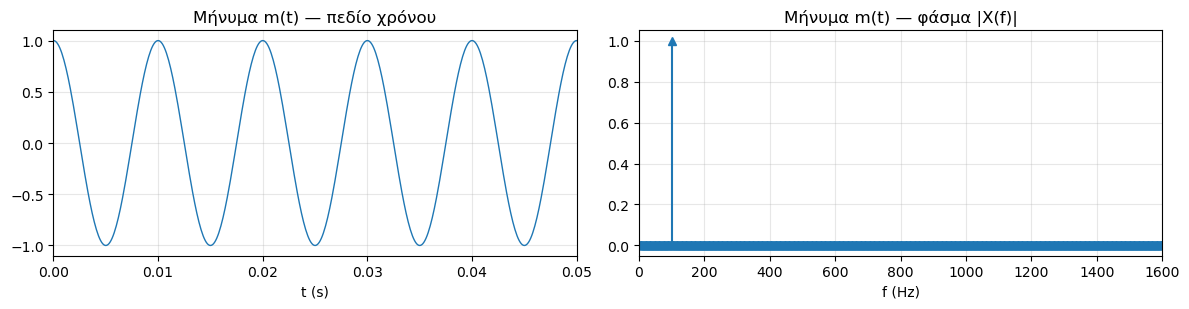

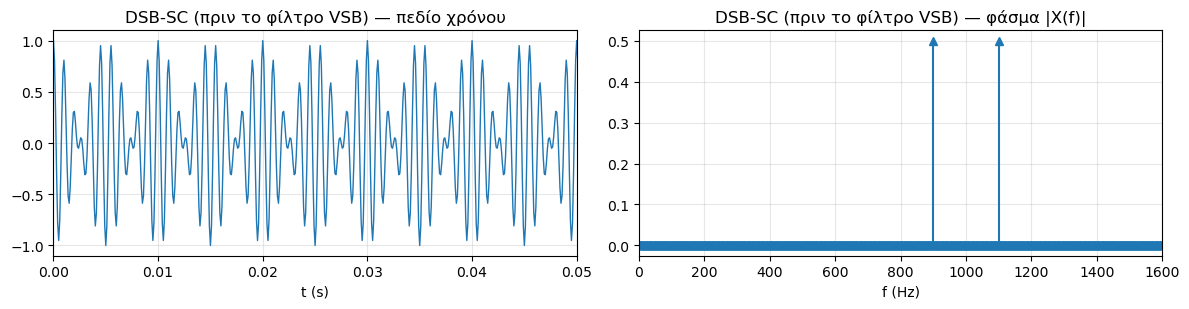

In [10]:
# ----- Παράμετροι (κοινές) -----
fs = 10000          # συχνότητα δειγματοληψίας (Hz)
N  = 4000           # πλήθος δειγμάτων (0.4 s)
t  = np.arange(N)/fs
fm = 100            # συχνότητα μηνύματος (Hz)
fc = 1000           # συχνότητα φέροντος (Hz)
Am = 1.0            # πλάτος μηνύματος
Ac = 1.0            # πλάτος φέροντος
wm = 2*np.pi*fm
wc = 2*np.pi*fc

m = Am*np.cos(wm*t)         # μήνυμα (ημιτονοειδές)
carrier = Ac*np.cos(wc*t)   # φέρον

fv = 150            # μισό εύρος μετάβασης του VSB (fv > fm)

dsb = Ac * m * np.cos(wc*t)      # DSB-SC πριν το φίλτρο VSB

tf(m, fs, 'Μήνυμα m(t)')
tf(dsb, fs, 'DSB-SC (πριν το φίλτρο VSB)')

### ii. Φίλτρο VSB και εφαρμογή

Ας δοκιμάσουμε τη VSB διαμόρφωση κρατώντας πλήρη την άνω πλευρική και ως υπολειμματική την κάτω πλευρική.

κέρδος άνω πλευρικής H(fc+fm) = 0.833
κέρδος κάτω πλευρικής H(fc-fm) = 0.167
άθροισμα (συμπληρωματική συμμετρία) = 1.000


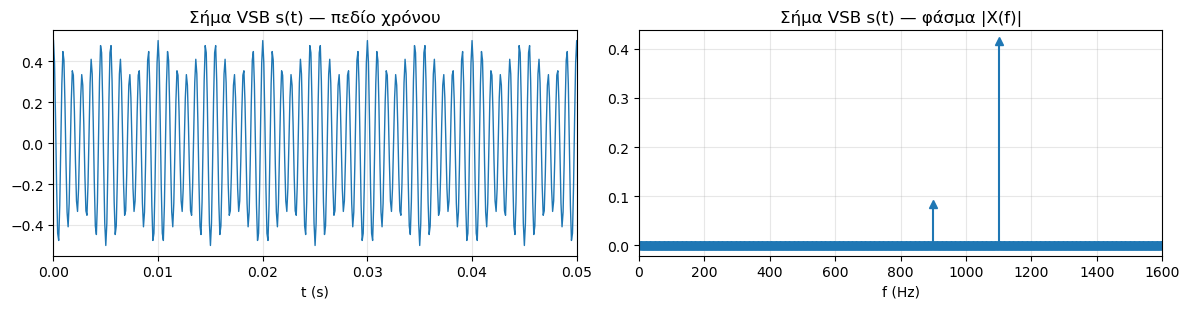

In [11]:
f_full = np.fft.fftfreq(N, 1/fs)
Habs = np.clip((np.abs(f_full)-(fc-fv))/(2*fv), 0.0, 1.0)   # Σχέση (3), άρτια -> πραγματικό σήμα
s = np.real(np.fft.ifft(np.fft.fft(dsb) * Habs))

gU = np.clip((fc+fm-(fc-fv))/(2*fv),0,1)
gL = np.clip((fc-fm-(fc-fv))/(2*fv),0,1)

print(f'κέρδος άνω πλευρικής H(fc+fm) = {gU:.3f}')
print(f'κέρδος κάτω πλευρικής H(fc-fm) = {gL:.3f}')
print(f'άθροισμα (συμπληρωματική συμμετρία) = {gU+gL:.3f}')

tf(s, fs, 'Σήμα VSB s(t)')

### iii. Απόκριση του φίλτρου VSB

Σχεδιάζουμε το $H_{\text{VSB}}(f)$ γύρω από το φέρον και σημειώνουμε τις δύο πλευρικές.

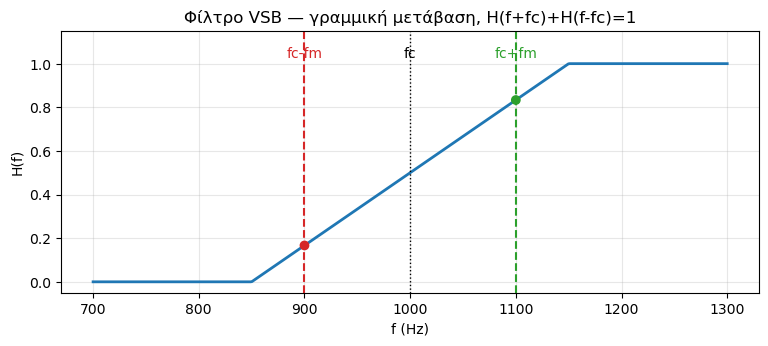

In [14]:
fpos = np.linspace(fc-2*fv, fc+2*fv, 500)
Hpos = np.clip((fpos-(fc-fv))/(2*fv), 0, 1)

plt.figure(figsize=(9,3.4))
plt.plot(fpos, Hpos, lw=2)
plt.axvline(fc, color='k', ls=':', lw=1); plt.text(fc, 1.03, 'fc', ha='center')
plt.axvline(fc+fm, color='tab:green', ls='--'); plt.text(fc+fm,1.03,'fc+fm',ha='center',color='tab:green')
plt.axvline(fc-fm, color='tab:red', ls='--'); plt.text(fc-fm,1.03,'fc-fm',ha='center',color='tab:red')
plt.scatter([fc+fm, fc-fm],[gU,gL], color=['tab:green','tab:red'], zorder=5)
plt.title('Φίλτρο VSB — γραμμική μετάβαση, H(f+fc)+H(f-fc)=1')
plt.xlabel('f (Hz)'); plt.ylabel('H(f)'); plt.grid(alpha=0.3); plt.ylim(-0.05,1.15)
plt.show()

### iv. Σύγχρονη αποδιαμόρφωση

Για την αποδιαμόρφωση, χρειαζόμαστε ένα ημιτονοειδές ίδιας συχνότητας με το φέρον σήμα, και ένα χαμηλοπερατό φίλτρο με κατάλληλη συχνότητα αποκοπής. Δείτε.

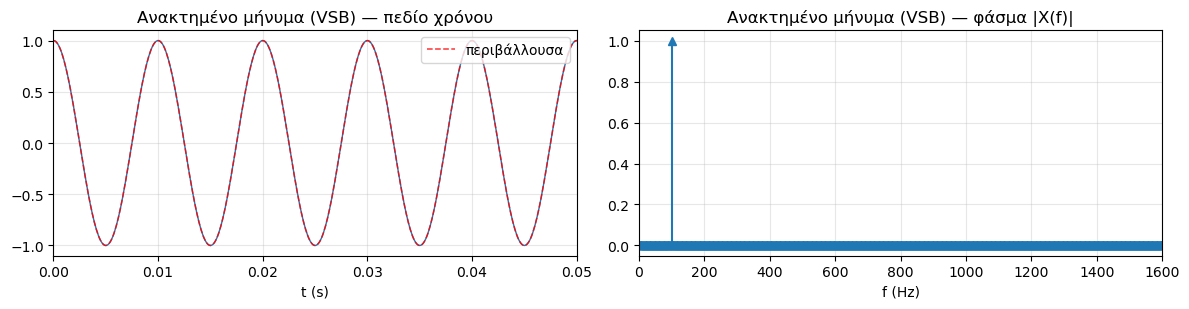

To μέγιστο σφάλμα ανάκτησης ισούται με 2.275e-13


In [15]:
v = s * np.cos(wc*t)
rec = lowpass(v, 1.5*fm, fs)
rec = rec / np.max(np.abs(rec[200:N-200]))   # κανονικοποίηση σχήματος

tf(rec, fs, 'Ανακτημένο μήνυμα (VSB)', ref=m)

sl = slice(300, N-300)
print(f'To μέγιστο σφάλμα ανάκτησης ισούται με {np.max(np.abs(rec[sl]-m[sl])):.3e}')

### Παρατηρήσεις

Το φάσμα VSB δείχνει καθαρά τη φιλοσοφία της μεθόδου: η άνω πλευρική ($1100$ Hz) περνά με κέρδος $\approx0.83$ ενώ η κάτω ($900$ Hz) μένει μόνο ως **υπόλειμμα** με κέρδος $\approx0.17$: το άθροισμά τους είναι $1$, δηλαδή ικανοποιείται η **συμπληρωματική συμμετρία** (Σχέση 2). Χάρη σε αυτήν, η σύγχρονη ανίχνευση ανακτά το ημιτονοειδές μήνυμα χωρίς παραμόρφωση σχήματος. 

Το εύρος ζώνης της VSB ($f_m<W_B<2f_m$) βρίσκεται ανάμεσα στις διαμορφώσεις SSB και DSB-SC, ενώ το ήπιο (γραμμικό) κόψιμο του φίλτρου την κάνει υλοποιήσιμη ακόμη και για σήματα με ενέργεια κοντά στο φέρον - γι' αυτό υιοθετήθηκε ιστορικά στην αναλογική τηλεόραση.

---
---